#### 🔐 API Keys Setup: OpenAI, Tavily & LangSmith | 🏗️ XTALLET

In [1]:
import os
import getpass

os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")

In [2]:
os.environ["TAVILY_API_KEY"] = getpass.getpass("TAVILY_API_KEY")

#### 📡 LangSmith Tracing Context Activation | 🏗️ XTALLET

In [3]:
from uuid import uuid4

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = f"AIE7-S11-Certification-Challenge-{uuid4().hex[0:8]}"
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("LangSmith API Key: ")

#### 📂 Load Dataset | 🏗️ XTALLET

In [4]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader

path = 'data/'
loader = DirectoryLoader(path, glob='*.pdf', loader_cls=PyMuPDFLoader)
docs = loader.load()
print(f'Number of documents loaded: {len(docs)}')

Number of documents loaded: 25


#### Prepare Text Splitter with Overlap | 🏗️ XTALLET

In [5]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
split_documents = text_splitter.split_documents(docs)
print(f'Number of chunks generated: {len(split_documents)}')

Number of chunks generated: 52


#### 🧬 Vectorization and in-memory Qdrant | 🏗️ XTALLET

In [6]:
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
client = QdrantClient(':memory:')
client.create_collection(
    collection_name='insurance_policy',
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)
vector_store = QdrantVectorStore(
    client=client,
    collection_name='insurance_policy',
    embedding=embeddings,
)
_ = vector_store.add_documents(documents=split_documents)
print('Vector store created and documents indexed.')

Vector store created and documents indexed.


#### 🔎 Define the Retriever | 🏗️ XTALLET

In [7]:
retriever = vector_store.as_retriever(search_kwargs={"k": 5})

#### 🧩 Retrieval Node Function | 🏗️ XTALLET

In [8]:
def retrieve(state):
    retrieved_docs = retriever.invoke(state["question"])
    return {"context": retrieved_docs}

#### 💬 RAG Prompt Template | 🏗️ XTALLET

In [9]:
from langchain.prompts import ChatPromptTemplate

RAG_PROMPT = """\
You are a helpful assistant who answers questions based on the provided context. You must only use the provided context, and cannot use your own knowledge.

### Question
{question}

### Context
{context}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

#### 🤖 Generation Node Function | 🏗️ XTALLET

In [10]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-nano")

def generate(state):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = rag_prompt.format_messages(question=state["question"], context=docs_content)
    response = llm.invoke(messages)
    return {"response": response.content}

#### 🔗 Build LangGraph RAG Pipeline | 🏗️ XTALLET

In [11]:
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class State(TypedDict):
    question: str
    context: List[Document]
    response: str

graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

#### 🗺️ Visualize LangGraph Pipeline Diagram | 🏗️ XTALLET

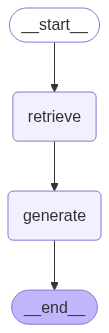

In [12]:
graph

#### 🧪 Test Baseline RAG Pipeline | 🏗️ XTALLET

In [13]:
response = graph.invoke({"question": "What is the UMR for my policy ?"})
print(response["response"])

The UMR for your policy is B1262SF0124814.


#### 🧪 Test Insurance RAG Tool Invocation | 🏗️ XTALLET

In [14]:
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage

@tool
def insurance_rag_tool(question: str) -> str:
	"""Useful for when you need to answer questions about insurance. Input should be a fully formed questions"""
	response = graph.invoke({"question": question})
	return {
		"messages": [HumanMessage(content=response["response"])],
		"context": response["context"]
}

ToolBelt

#### 🧰 Tool Belt Configuration: RAG, Tavily & Arxiv | 🏗️ XTALLET

In [15]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.tools.arxiv.tool import ArxivQueryRun

tavily_tool = TavilySearchResults(max_results=5)

tool_belt = [
    insurance_rag_tool,
    tavily_tool,
    ArxivQueryRun()
]

/tmp/ipykernel_8397/3190548365.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=5)


#### 🧠 LLM Initialization with GPT-4.1-Nano | 🏗️ XTALLET

In [16]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model="gpt-4.1-nano", temperature=0)

#### 🧩 Binding Tools to LLM Instance | 🏗️ XTALLET

In [17]:
model = model.bind_tools(tool_belt)

#### 🗂️ Agent State Definition with Messages and Context | 🏗️ XTALLET

In [18]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
import operator
from langchain_core.messages import BaseMessage
from langchain_core.documents import Document

class AgentState(TypedDict):
  messages: Annotated[list, add_messages]
  context: List[Document]

#### 🔄 Pre-RAG Context Handling & Model Invocation Logic | 🏗️ XTALLET

In [19]:
from langgraph.prebuilt import ToolNode

def pre_rag_context(state: AgentState):
    question = state["messages"][-1].content
    print(f'The user question is : {question}')
    rag_result = graph.invoke({"question": question})
    print(f'The rag result is : {rag_result}')
    return {
        "messages": state["messages"],
        "context": rag_result["context"]  # Esto se pasa a `agent`
    }

def call_model(state):
    question_msg = state["messages"][-1]
    context_docs = state.get("context", [])
    
    docs_content = "\n\n".join(doc.page_content for doc in context_docs)

    # Usa el mismo prompt que en generate()
    messages = rag_prompt.format_messages(
        question=question_msg.content,
        context=docs_content
    )

    response = model.invoke(messages)

    return {
        "messages": [response],
        "context": context_docs
    }

tool_node = ToolNode(tool_belt)

#### 🧱 Building StateGraph Nodes: Pre-RAG, Agent, and Action | 🏗️ XTALLET

In [20]:
from langgraph.graph import StateGraph, END

uncompiled_graph = StateGraph(AgentState)

uncompiled_graph.add_node("pre_rag_context", pre_rag_context)
uncompiled_graph.add_node("agent", call_model)
uncompiled_graph.add_node("action", tool_node)

#### 🔗 Setting Entry Point and Connecting Graph Nodes | 🏗️ XTALLET

In [21]:
uncompiled_graph.set_entry_point("pre_rag_context")
uncompiled_graph.add_edge("pre_rag_context", "agent")

#### 🔄 Conditional Transition Logic for Graph Execution | 🏗️ XTALLET

In [22]:
def should_continue(state):
  last_message = state["messages"][-1]

  if last_message.tool_calls:
    return "action"

  return END

uncompiled_graph.add_conditional_edges(
    "agent",
    should_continue
)

#### 🔁 Looping Edge from Action Back to Agent Node | 🏗️ XTALLET

In [23]:
uncompiled_graph.add_edge("action", "agent")

#### ⚙️ Compiling the StateGraph into Executable Agent Graph | 🏗️ XTALLET

In [24]:
simple_agent_graph = uncompiled_graph.compile()

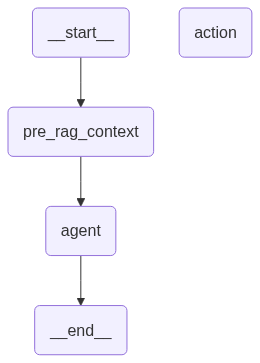

In [25]:
simple_agent_graph

#### 📡 Streaming Agent Graph Execution with Async Updates | 🏗️ XTALLET

In [26]:
from langchain_core.messages import HumanMessage

#inputs = {"messages" : [HumanMessage(content="What is the Unique Reference Market (UMR) for my policy ?")]}
inputs = {"messages" : [HumanMessage(content="Is the 'Institute Radioactive Contamination Exclusion Clause 10/11/03' still considered current industry standard in 2025?")]}

async for chunk in simple_agent_graph.astream(inputs, stream_mode="updates"):
    #print(f'chunk : {chunk}')
    for node, values in chunk.items():
        #print(f'node : {node} and values : {values}')
        print(f"Receiving update from node: '{node}'")
        print(values["messages"])
        print("\n\n")

The user question is : Is the 'Institute Radioactive Contamination Exclusion Clause 10/11/03' still considered current industry standard in 2025?
The rag result is : {'question': "Is the 'Institute Radioactive Contamination Exclusion Clause 10/11/03' still considered current industry standard in 2025?", 'context': [Document(metadata={'producer': 'Microsoft® Word 2010', 'creator': 'Microsoft® Word 2010', 'creationdate': '2015-08-07T17:35:36-04:00', 'source': 'data/F24716_AttachmentAExpiring1415PolicySoFComplete.pdf', 'file_path': 'data/F24716_AttachmentAExpiring1415PolicySoFComplete.pdf', 'total_pages': 25, 'format': 'PDF 1.6', 'title': 'REINSURANCE STANDARD SLIP - PART 1', 'author': 'Arthur J. Gallagher (UK) Ltd.', 'subject': '', 'keywords': '', 'moddate': '2015-08-07T17:36:28-04:00', 'trapped': '', 'modDate': "D:20150807173628-04'00'", 'creationDate': "D:20150807173536-04'00'", 'page': 14, '_id': '6b26927537a94add86a53c80a3c64743', '_collection_name': 'insurance_policy'}, page_content

#### 🧪 Generate Synthetic "Golden Dataset" for Evaluation | 🏗️ XTALLET

In [29]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from ragas.testset import TestsetGenerator

generator_llm = LangchainLLMWrapper(
    ChatOpenAI(model="gpt-4.1", verbose=True)
)
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())
generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)

dataset = generator.generate_with_langchain_docs(split_documents, testset_size=10)

print("✅ Synthetic golden dataset generated.")

Applying SummaryExtractor:   0%|          | 0/44 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/52 [00:00<?, ?it/s]

Node 17093baa-4113-4b49-9386-8973a6342b9e does not have a summary. Skipping filtering.
Node 08c5adbe-6da3-40fc-b37a-911b7ddcbf52 does not have a summary. Skipping filtering.
Node 5afe728d-ad43-4960-ac66-d098be707dd3 does not have a summary. Skipping filtering.
Node 0e247b01-beb0-4883-b088-5ee03cb733cc does not have a summary. Skipping filtering.
Node 3e665319-9514-48c1-b16f-83607988afd6 does not have a summary. Skipping filtering.
Node 6355a6f1-d5d8-4ccc-ab5b-958c9dcc1879 does not have a summary. Skipping filtering.
Node 37453a95-3f3a-4f00-bad9-09196f0f5e35 does not have a summary. Skipping filtering.
Node 3c09c503-611c-440a-9f36-a63a5780ac57 does not have a summary. Skipping filtering.


Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/148 [00:00<?, ?it/s]

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/12 [00:00<?, ?it/s]

✅ Synthetic golden dataset generated.


#### 🚀 Run Baseline RAG Pipeline on Evaluation Dataset | 🏗️ XTALLET

In [34]:
for test_row in dataset:
    response = graph.invoke({"question": test_row.eval_sample.user_input})
    test_row.eval_sample.response = response["response"]
    test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]

#### 📝 Convert Generated Dataset to Pandas and visualize it | 🏗️ XTALLET

In [35]:
import pandas as pd
from ragas import EvaluationDataset

df = dataset.to_pandas()
pd.set_option('display.max_colwidth', 200)
display(df)

print("✅ EvaluationDataset prepared from synthetic dataset.")

,user_input,retrieved_contexts,reference_contexts,response,reference,synthesizer_name
0,Whaat is the role of the Finnancial Conduct Authoority in the contexxt of Arthur J. Gallagher (UK) Limited's insurrance contrracts?,[Arthur J. Gallagher (UK) Limited \nREGISTRATION NO. Page 17 of 21 \nUMR: B1262SF0124814 \n1262 \n \nAJG \n \n \nBkr initial \n \nL/U initial \n \n \n \n \n \n \n \n \nSanction Limitation And Excl...,[ARTHUR J. GALLAGHER (UK) LIMITED \n \n \n \n \n \nAJG 1262 \n \nCONTRACT ENDORSEMENT \nUnique Market Reference: B1262SF0124814 \nEndorsement Reference: 1 \nReinsured: None \nOriginal Insured: STA...,The role of the Financial Conduct Authority (FCA) in the context of Arthur J. Gallagher (UK) Limited's insurance contracts is to regulate the company as an authorized entity. The FCA authorizes an...,"Arthur J. Gallagher (UK) Limited is authorised and regulated by the Financial Conduct Authority (authorisation number 312919), as stated in the contract endorsement.",single_hop_specifc_query_synthesizer
1,Wht is the sum insurred for Outdor Sculptures?,"[Nil. \n \n \n \nOutdoor Sculptures: \n \n \nUSD1,000.00 each and every loss increasing to USD5,000.00 in respect of \nvandalism and malicious damage increasing further to USD10,000.00 in \nrespec...",[Each Underwriter’s proportion is several not joint \n \nSlip Leader Only \nSlip Leader \nAnd \nAgreement Parties \nAll Underwriters \n \nNotification to followers \nYes / No \nWithin _________w...,"The sum insured for Outdoor Sculptures is USD3,242,830 any one loss whilst at the locations of the Insured.","The sum insured for Outdoor Sculptures is USD3,497,330 any one loss whilst at the locations of the Insured.",single_hop_specifc_query_synthesizer
2,What is the role of the Financial Conduct Authority in relation to Arthur J. Gallagher (UK) Limited as indicated in the contract endorsement?,[ARTHUR J. GALLAGHER (UK) LIMITED \n \n \n \n \n \nAJG 1262 \n \nCONTRACT ENDORSEMENT \nUnique Market Reference: B1262SF0124814 \nEndorsement Reference: 1 \nReinsured: None \nOriginal Insured: STA...,[ARTHUR J. GALLAGHER (UK) LIMITED \n \n \n \n \n \nAJG 1262 \n \nCONTRACT ENDORSEMENT \nUnique Market Reference: B1262SF0124814 \nEndorsement Reference: 1 \nReinsured: None \nOriginal Insured: STA...,"The role of the Financial Conduct Authority in relation to Arthur J. Gallagher (UK) Limited, as indicated in the contract endorsement, is that of a regulatory authority that authorizes and regulat...","Arthur J. Gallagher (UK) Limited is authorised and regulated by the Financial Conduct Authority, as stated in the contract endorsement.",single_hop_specifc_query_synthesizer
3,"What is the role of an Underwriter in the context of exhibition insurance, and how is their proportion determined according to the provided terms?",[Each Underwriter’s proportion is several not joint \n \nSlip Leader Only \nSlip Leader \nAnd \nAgreement Parties \nAll Underwriters \n \nNotification to followers \nYes / No \nWithin _________w...,[Each Underwriter’s proportion is several not joint \n \nSlip Leader Only \nSlip Leader \nAnd \nAgreement Parties \nAll Underwriters \n \nNotification to followers \nYes / No \nWithin _________w...,"In the context of exhibition insurance, the role of an Underwriter is to assess and accept the risk associated with insuring the property, such as outdoor sculptures and fine art, and to provide c...","According to the provided context, each Underwriter’s proportion is several, not joint, meaning each Underwriter is responsible only for their own share and not for the shares of others. The conte...",single_hop_specifc_query_synthesizer
4,"What is the process for issuing a non-renewal notice for insurance coverage of art assets located at multiple university campuses, and how much coverage is provided at each location?",[Insured. \n \nINTEREST: \nFine Art of every nature and description being property of the Insured \nand/or for which they have accepted responsibility to insure. \n \nSUM IN

✅ EvaluationDataset prepared from synthetic dataset.


#### 📊 Convert to Ragas EvaluationDataset | 🏗️ XTALLET

In [36]:
from ragas import EvaluationDataset

evaluation_dataset = EvaluationDataset.from_pandas(dataset.to_pandas())

#### 📊 Evaluate with RAGAS Metrics (Semantic Chunking) | 🏗️ XTALLET

In [37]:
from ragas import evaluate
from ragas.llms import LangchainLLMWrapper
from langchain_openai import ChatOpenAI
from ragas.metrics import (
    LLMContextRecall,
    Faithfulness,
    ResponseRelevancy,
    ContextEntityRecall,
)
from ragas import RunConfig

evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))
custom_run_config = RunConfig(timeout=360)

result = evaluate(
    dataset=evaluation_dataset,
    metrics=[
        LLMContextRecall(),
        Faithfulness(),
        ResponseRelevancy(),
        ContextEntityRecall()
    ],
    llm=evaluator_llm,
    run_config=custom_run_config
)
print(result)

Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

{'context_recall': 0.8819, 'faithfulness': 0.7722, 'answer_relevancy': 0.8787, 'context_entity_recall': 0.5162}


#### Task 6 - What conclusions can you draw about the performance and effectiveness of your pipeline with this information?

<b>Definitions :</b><br>
`LLMContextRecall()` : Measures how much of the relevant context was retrieved to answer the question.<br>
`Faithfulness()` : Checks if the answer is strictly supported by the retrieved context.<br>
`ResponseRelevancy()` : Evaluates how relevant the answer is to the user's question.<br>
`ContextEntityRecall()` : Measures how many key entities from the reference are present in the retrieved context.<br>

Based on the RAGAS evaluation results, the pipeline demonstrates strong performance in context retrieval (0.8819 context recall) and response relevance (0.8787), indicating effective information gathering and answer generation capabilities. However, the lower context entity recall (0.5162) suggests room for improvement in retrieving specific named entities and precise information chunks. The faithfulness score (0.7722) shows good adherence to source material while maintaining some flexibility in response generation. Overall, the pipeline effectively balances comprehensive information retrieval with relevant answer generation, though optimizing entity-level precision could enhance its effectiveness for queries requiring specific details or factual accuracy.

#### ⚙️ Define Retriever Evaluation Function Using Ragas & LangSmith | 🏗️ XTALLET

#### ▶️ Evaluate Naive Retriever Chain | 🏗️ XTALLET

In [ ]:
naive_results = evaluate_retriever("Naive Retriever", naive_retrieval_chain, dataset)